In [1]:
import Pkg; Pkg.add("ITensors")

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\AVM11\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\AVM11\.julia\environments\v1.12\Manifest.toml`


In [2]:
using DelimitedFiles
using Pkg
Pkg.activate("../")  # Activate the main project
using Dleto
using Random
using ITensors
using Statistics
using Plots
using Combinatorics

  Activating project at `c:\Users\AVM11\GitHub\OpenDleto`


WebIO._IJuliaInit()

Loading Dleto Plots Extension


In [11]:

function process_high_school_hypergraph(k::Int; seed::Union{Int,Nothing}=nothing, number_label::Union{Int,String}=1)
  
    # Load the contact-high-school temporal hypergraph dataset


    # Load the three data files
    nverts_file = "contact-high-school/contact-high-school-nverts.txt"
    simplices_file = "contact-high-school/contact-high-school-simplices.txt"
    times_file = "contact-high-school/contact-high-school-times.txt"

    # Read number of vertices per simplex
    nverts_full = vec(readdlm(nverts_file, Int))
    println("Total number of simplices: ", length(nverts_full))

    # Read all simplex node IDs (contiguous list)
    all_nodes_full = vec(readdlm(simplices_file, Int))
    println("Total node entries: ", length(all_nodes_full))

    # Read timestamps
    timestamps_full = vec(readdlm(times_file, Int))
    println("Total timestamps: ", length(timestamps_full))

    # Filter to random k nodes only
    all_unique_nodes = sort(unique(all_nodes_full))
    if seed !== nothing
        Random.seed!(seed)
        println("Random seed set to $seed")
    end
    random_k_nodes = Set(shuffle(all_unique_nodes)[1:k])
    println("Filtering to random $k nodes: $(sort(collect(random_k_nodes)))")

    # Filter simplices to only include those with all nodes in random_k_nodes
    filtered_indices = Int[]
    node_idx = 1
    for (simplex_idx, nvert) in enumerate(nverts_full)
        simplex_nodes = all_nodes_full[node_idx:(node_idx + nvert - 1)]
        if all(node in random_k_nodes for node in simplex_nodes)
            push!(filtered_indices, simplex_idx)
        end
        node_idx += nvert
    end

    # Create filtered datasets
    nverts = nverts_full[filtered_indices]
    timestamps = timestamps_full[filtered_indices]

    # Rebuild all_nodes for filtered simplices
    all_nodes = Int[]
    for simplex_idx in filtered_indices
        nvert = nverts_full[simplex_idx]
        orig_pos = sum(nverts_full[1:simplex_idx-1]) + 1
        simplex_nodes = all_nodes_full[orig_pos:(orig_pos + nvert - 1)]
        append!(all_nodes, simplex_nodes)
    end
    max_view = length(unique(all_nodes))
    println("\nFiltered dataset statistics:")
    println("Number of timestamped simplices: ", length(nverts))
    println("Number of unique node IDs: ", length(unique(all_nodes)))
    println("Simplex size distribution:")
    size_counts = Dict{Int, Int}()
    for size in nverts
        size_counts[size] = get(size_counts, size, 0) + 1
    end
    for size in sort(collect(keys(size_counts)))
        count = size_counts[size]
        println("  Size $size: $count simplices")
    end

    # Parse simplices from the contiguous node list
    simplices = Vector{Vector{Int}}()
    node_idx = 1
    for nvert in nverts
        simplex_nodes = all_nodes[node_idx:(node_idx + nvert - 1)]
        push!(simplices, simplex_nodes)
        node_idx += nvert
    end
    println("Parsed ", length(simplices), " simplices")
    println("First few simplices:")
    for i in 1:min(10, length(simplices))
        println("  Simplex $i (time $(timestamps[i])): $(simplices[i])")
    end

    # Create simple temporal simplex structure for processing
    temporal_simplices = [(simplices[i], timestamps[i], nverts[i]) for i in 1:length(simplices)]
    println("Created temporal hypergraph with ", length(temporal_simplices), " temporal simplices")

    # Basic statistics
    all_unique_nodes = sort(unique(all_nodes))
    println("Number of nodes: ", length(all_unique_nodes))
    println("Time range: $(minimum(timestamps)) to $(maximum(timestamps))")
    println("\nReady for tensor creation!")

    # Create a 3-mode tensor by decomposing hyperedges into 3-node subsets
    println("Creating 3-mode tensor from hyperedge decomposition ($k nodes only)...")
    unique_nodes = all_unique_nodes[1:max_view]
    node_to_idx = Dict(node => i for (i, node) in enumerate(unique_nodes))
    n_nodes = max_view
    println("Tensor dimensions:")
    println("  Node 1: $n_nodes")
    println("  Node 2: $n_nodes")
    println("  Node 3: $n_nodes")
    println("  Total entries: $(n_nodes^3)")
    println("  Using nodes: $(minimum(unique_nodes)) to $(maximum(unique_nodes))")

    function get_3node_combinations(nodes)
        if length(nodes) < 3
            return []
        elseif length(nodes) == 3
            return [nodes]
        else
            combinations = []
            for i in 1:length(nodes)-2
                for j in i+1:length(nodes)-1
                    for k in j+1:length(nodes)
                        push!(combinations, [nodes[i], nodes[j], nodes[k]])
                    end
                end
            end
            return combinations
        end
    end

    # Create ITensor indices for the 3-mode tensor
    i = Index(n_nodes, "node1")
    j = Index(n_nodes, "node2")
    k = Index(n_nodes, "node3")
    Triangles = ITensor(Float32, i, j, k)

    # Populate the tensor by counting 3-node combinations
    processed_simplices = 0
    total_triangles = 0
    skipped_small = 0
    for (idx, ts) in enumerate(temporal_simplices)
        triangle_combinations = get_3node_combinations(ts[1]) # ts[1] is the nodes vector
        if isempty(triangle_combinations)
            skipped_small += 1
            continue
        end
        for triangle in triangle_combinations
            node_indices = []
            for node in triangle
                if node in keys(node_to_idx) # Double check that all nodes are within our random sample
                    push!(node_indices, node_to_idx[node])
                end

            end
            if length(node_indices) == 3
                a, b, c = node_indices[1], node_indices[2], node_indices[3]
                Triangles[i=>a, j=>b, k=>c] += 1.0
                Triangles[i=>a, j=>c, k=>b] += 1.0
                Triangles[i=>b, j=>a, k=>c] += 1.0
                Triangles[i=>b, j=>c, k=>a] += 1.0
                Triangles[i=>c, j=>a, k=>b] += 1.0
                Triangles[i=>c, j=>b, k=>a] += 1.0
                total_triangles += 1
            end
        end
        processed_simplices += 1
    end

    
    # After populating Triangles and before tensor analysis
    # Output filtered hyperedges (unique, no permutations)
    hyperedges_filename = "filtered_hyperedges_$(string(number_label)).txt" 
    written = Set{Tuple{Int,Int,Int}}()   
    open(hyperedges_filename, "w") do io
        for a in 1:n_nodes, b in 1:n_nodes, c in 1:n_nodes
            if Triangles[i=>a, j=>b, k=>c] == 1.0
                edge = sort((a, b, c)) # sort to ignore permutations
                if !(edge in written)
                    print(io, "[", join(edge, ","), "]; ")
                    push!(written, edge)
                end
            end
        end
    end
    println("Filtered hyperedges saved to $hyperedges_filename")

    # Output all permutations of each unique hyperedge
    permuted_filename = "filtered_hyperedges_permuted_$(string(number_label)).txt"
    open(permuted_filename, "w") do io
        for edge in written
            perms = collect(permutations(edge))
            for p in perms
                print(io, "(", join(p, ","), "); ")
            end
        end
    end
    println("Permuted hyperedges saved to $permuted_filename")




    # Analyze the tensor
    T_array = Array(Triangles, i, j, k)
    non_zero_entries = count(x -> x != 0, T_array)
    total_entries = length(T_array)
    println("✅ 3-mode triangle tensor created!")
    println("Processed simplices: $processed_simplices")
    println("Skipped simplices (< 3 nodes): $skipped_small")
    println("Total triangles extracted: $total_triangles")
    println("Non-zero tensor entries: $non_zero_entries / $total_entries")
    println("Sparsity: $(round((total_entries - non_zero_entries) / total_entries * 100, digits=1))%")
    println("Max triangle count: $(Int(maximum(T_array)))")
    println("Mean triangle count: $(round(mean(T_array[T_array .> 0]), digits=2))")

    # Plot the tensor
    # plot_tensor(Triangles, title="High School Contact Triangle Tensor")

    # Create a k×k×k subsample tensor for faster processing
    println("Creating $k×$k×$k subsample tensor...")
    max = max_view
    i_small = Index(max, "node1_small")
    j_small = Index(max, "node2_small")
    k_small = Index(max, "node3_small")
    SmallHigh = ITensor(i_small, j_small, k_small)
    T_small_array = T_array[1:max, 1:max, 1:max]
    for a in 1:max, b in 1:max, c in 1:max
        if T_small_array[a, b, c] != 0
            SmallHigh[i_small=>a, j_small=>b, k_small=>c] = T_small_array[a, b, c]
        end
    end
    small_non_zero = count(x -> x != 0, T_small_array)
    small_total = length(T_small_array)
    println("✅ Subsample tensor created!")

    # Perform stratified decomposition on the subsample
    println("\n🔬 Performing stratified decomposition on SmallHigh tensor...")
    @time SmallHigh_strat, Xs_strat_small = stratify(SmallHigh)
    println("✅ SmallHigh stratification complete!")

    # Plot SmallHigh and SmallHigh_strat side by side
    p1 = plot_tensor(SmallHigh; title="Original SmallHigh", color=:blue)
    p2 = plot_tensor(SmallHigh_strat; title="Stratified SmallHigh", color=:red)
    Plots.plot(p1, p2; layout=(1,2), size=(800,400))

end

process_high_school_hypergraph (generic function with 1 method)

Total number of simplices: 172035
Total node entries: 352718
Total timestamps: 172035
Filtering to random 80 nodes: [1, 2, 8, 10, 11, 25, 26, 27, 32, 38, 40, 42, 56, 59, 62, 66, 68, 78, 83, 86, 94, 95, 99, 103, 104, 123, 126, 132, 134, 139, 151, 162, 167, 169, 170, 171, 172, 175, 176, 177, 179, 183, 185, 188, 192, 193, 195, 199, 201, 203, 210, 216, 218, 220, 222, 223, 228, 230, 231, 233, 234, 238, 240, 243, 255, 259, 264, 265, 268, 270, 272, 290, 291, 301, 303, 305, 309, 310, 318, 320]

Filtered dataset statistics:
Number of timestamped simplices: 9688
Number of unique node IDs: 80
Simplex size distribution:
  Size 2: 9510 simplices
  Size 3: 177 simplices
  Size 4: 1 simplices
Parsed 9688 simplices
First few simplices:
  Simplex 1 (time 1385982020): [2, 1]
  Simplex 2 (time 1385982020): [26, 25]
  Simplex 3 (time 1385982040): [2, 1]
  Simplex 4 (time 1385982040): [26, 25]
  Simplex 5 (time 1385982060): [2, 1]
  Simplex 6 (time 1385982060): [26, 25]
  Simplex 7 (time 1385982080): [2, 1

[ Info: Found 10 derivations for stratification.


2302.941791 seconds (1.53 G allocations: 1.306 TiB, 4.20% gc time, 0.50% compilation time: 3% of which was recompilation)
✅ SmallHigh stratification complete!


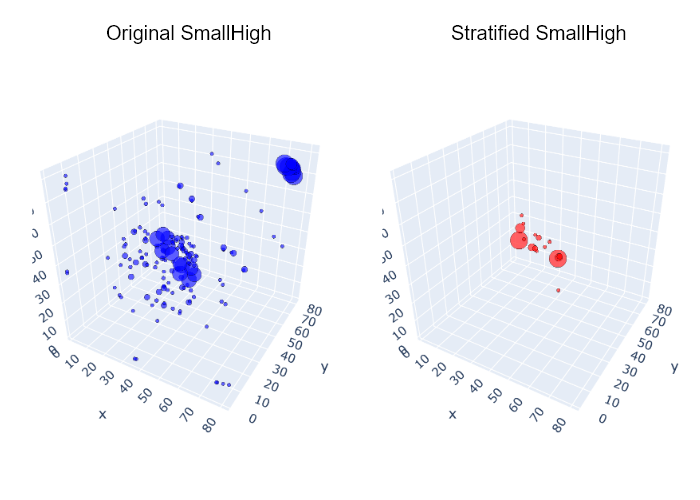

In [12]:
process_high_school_hypergraph(80; number_label=1)

In [14]:
process_high_school_hypergraph(80; number_label=2)

Total number of simplices: 172035
Total node entries: 352718
Total timestamps: 172035
Filtering to random 80 nodes: [2, 5, 6, 8, 15, 18, 19, 21, 23, 25, 28, 29, 33, 37, 47, 53, 60, 64, 66, 74, 76, 77, 78, 83, 86, 87, 90, 97, 99, 105, 107, 115, 123, 131, 132, 134, 137, 143, 151, 158, 160, 168, 170, 181, 186, 187, 188, 191, 194, 203, 205, 212, 216, 225, 233, 237, 238, 239, 243, 245, 250, 256, 257, 264, 268, 270, 271, 276, 279, 280, 281, 292, 300, 301, 305, 307, 309, 311, 313, 327]

Filtered dataset statistics:
Number of timestamped simplices: 10671
Number of unique node IDs: 80
Simplex size distribution:
  Size 2: 10631 simplices
  Size 3: 40 simplices
Parsed 10671 simplices
First few simplices:
  Simplex 1 (time 1385982020): [29, 28]
  Simplex 2 (time 1385982020): [5, 6]
  Simplex 3 (time 1385982040): [29, 76]
  Simplex 4 (time 1385982040): [5, 6]
  Simplex 5 (time 1385982060): [29, 76]
  Simplex 6 (time 1385982060): [78, 77]
  Simplex 7 (time 1385982060): [5, 6]
  Simplex 8 (time 13859

[ Info: Found 10 derivations for stratification.


2287.389010 seconds (1.49 G allocations: 1.304 TiB, 4.23% gc time)
✅ SmallHigh stratification complete!


┌ Warning: No tensor entries exceed the threshold of 0.0001. Nothing to plot.
└ @ DletoPlotsExt c:\Users\AVM11\GitHub\OpenDleto\ext\DletoPlotsExt.jl:254


LoadError: MethodError: no method matching axes(::Nothing, ::Int64)
The function `axes` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  axes([91m::Core.SimpleVector[39m, ::Integer)
[0m[90m   @[39m [90mBase[39m [90m[4messentials.jl:946[24m[39m
[0m  axes([91m::LinearMaps.LinearMap[39m, ::Integer)
[0m[90m   @[39m [35mLinearMaps[39m [90mC:\Users\AVM11\.julia\packages\LinearMaps\KV78T\src\[39m[90m[4mLinearMaps.jl:64[24m[39m
[0m  axes([91m::LinearAlgebra.AbstractQ[39m, ::Integer)
[0m[90m   @[39m [32mLinearAlgebra[39m [90mC:\Users\AVM11\.julia\juliaup\julia-1.12.2+0.x64.w64.mingw32\share\julia\stdlib\v1.12\LinearAlgebra\src\[39m[90m[4mabstractq.jl:76[24m[39m
[0m  ...


Total number of simplices: 172035
Total node entries: 352718
Total timestamps: 172035
Filtering to random 80 nodes: [1, 16, 17, 22, 25, 26, 28, 30, 35, 36, 44, 46, 51, 56, 57, 61, 64, 68, 73, 74, 75, 78, 80, 84, 91, 92, 109, 115, 118, 121, 126, 130, 138, 143, 146, 149, 150, 161, 163, 166, 168, 171, 174, 182, 183, 185, 191, 194, 196, 198, 199, 202, 204, 210, 219, 221, 225, 226, 229, 231, 234, 235, 236, 242, 269, 270, 272, 275, 276, 278, 279, 286, 287, 292, 301, 305, 316, 318, 322, 327]

Filtered dataset statistics:
Number of timestamped simplices: 14928
Number of unique node IDs: 79
Simplex size distribution:
  Size 2: 14569 simplices
  Size 3: 355 simplices
  Size 4: 4 simplices
Parsed 14928 simplices
First few simplices:
  Simplex 1 (time 1385982020): [26, 25]
  Simplex 2 (time 1385982020): [16, 17]
  Simplex 3 (time 1385982020): [61, 16]
  Simplex 4 (time 1385982040): [26, 25]
  Simplex 5 (time 1385982040): [75, 74]
  Simplex 6 (time 1385982040): [61, 16]
  Simplex 7 (time 1385982060

[ Info: Found 10 derivations for stratification.


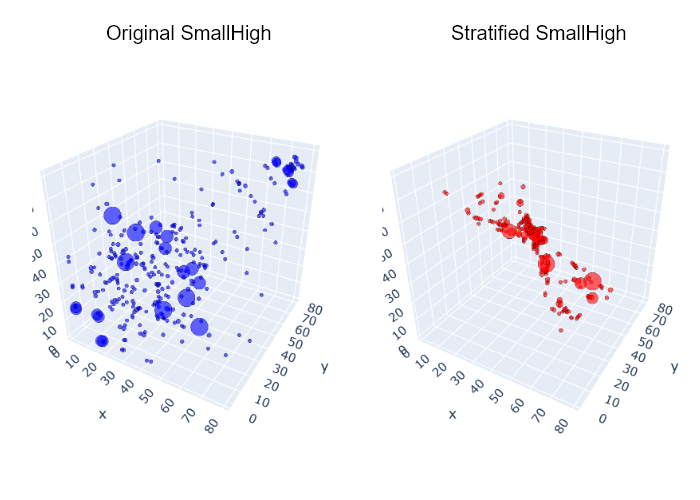

In [15]:
process_high_school_hypergraph(80; number_label=3)

Total number of simplices: 172035
Total node entries: 352718
Total timestamps: 172035
Filtering to random 80 nodes: [10, 12, 13, 14, 20, 21, 28, 33, 35, 37, 38, 39, 43, 48, 51, 52, 54, 55, 63, 66, 73, 78, 84, 85, 95, 103, 110, 111, 116, 118, 131, 135, 137, 141, 143, 145, 146, 152, 153, 157, 163, 164, 168, 172, 174, 178, 185, 186, 198, 201, 205, 210, 217, 223, 224, 232, 251, 252, 257, 260, 263, 264, 268, 270, 276, 279, 280, 281, 283, 285, 291, 294, 295, 298, 299, 302, 305, 310, 312, 315]

Filtered dataset statistics:
Number of timestamped simplices: 10898
Number of unique node IDs: 80
Simplex size distribution:
  Size 2: 10616 simplices
  Size 3: 281 simplices
  Size 4: 1 simplices
Parsed 10898 simplices
First few simplices:
  Simplex 1 (time 1385982020): [51, 52]
  Simplex 2 (time 1385982020): [13, 12]
  Simplex 3 (time 1385982040): [13, 12]
  Simplex 4 (time 1385982060): [51, 52]
  Simplex 5 (time 1385982060): [13, 12]
  Simplex 6 (time 1385982080): [28, 85]
  Simplex 7 (time 13859820

[ Info: Found 10 derivations for stratification.


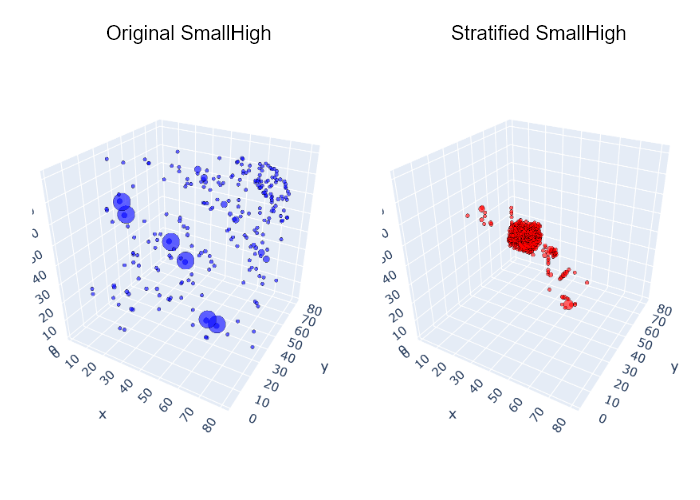

In [16]:
process_high_school_hypergraph(80; number_label=4)

Total number of simplices: 172035
Total node entries: 352718
Total timestamps: 172035
Filtering to random 80 nodes: [10, 12, 15, 17, 19, 25, 32, 37, 38, 39, 41, 46, 50, 52, 56, 59, 71, 85, 88, 93, 96, 97, 98, 106, 121, 123, 126, 127, 129, 130, 141, 144, 145, 147, 148, 155, 159, 162, 168, 174, 179, 185, 190, 194, 197, 199, 201, 202, 212, 222, 225, 228, 231, 232, 237, 245, 248, 262, 267, 271, 276, 282, 283, 285, 286, 287, 288, 290, 298, 299, 300, 302, 307, 310, 312, 318, 320, 322, 324, 326]

Filtered dataset statistics:
Number of timestamped simplices: 7923
Number of unique node IDs: 80
Simplex size distribution:
  Size 2: 7889 simplices
  Size 3: 33 simplices
  Size 4: 1 simplices
Parsed 7923 simplices
First few simplices:
  Simplex 1 (time 1385982100): [25, 93]
  Simplex 2 (time 1385982160): [71, 25]
  Simplex 3 (time 1385982180): [71, 25]
  Simplex 4 (time 1385982200): [106, 12]
  Simplex 5 (time 1385982220): [71, 39]
  Simplex 6 (time 1385982220): [93, 39]
  Simplex 7 (time 138598224

[ Info: Found 10 derivations for stratification.


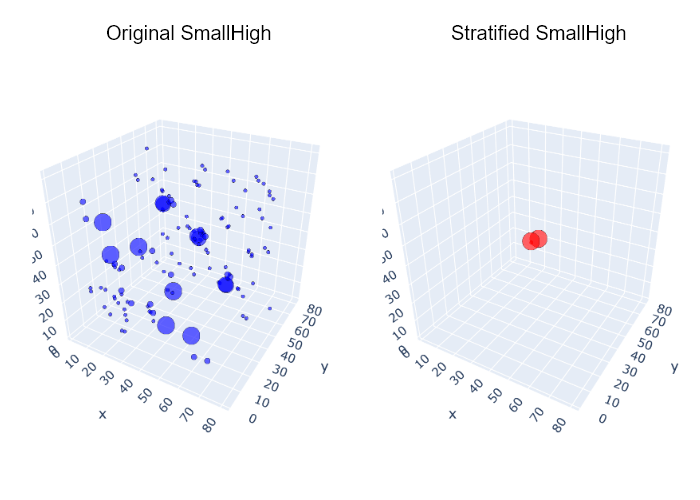

In [17]:
process_high_school_hypergraph(80; number_label=5)

In [18]:
# process_high_school_hypergraph(60)

In [19]:
# process_high_school_hypergraph(90)

In [20]:
# process_high_school_hypergraph(90)

In [21]:
# process_high_school_hypergraph(90)

In [22]:
# process_high_school_hypergraph(150)

In [23]:
# process_high_school_hypergraph(150)

In [24]:
# process_high_school_hypergraph(150)

In [25]:
# process_high_school_hypergraph(200)

In [26]:
# process_high_school_hypergraph(200)

In [27]:
# process_high_school_hypergraph(200)